#### Imports

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Load Database

- Repeat using every CSV

In [ ]:
df = pd.read_csv('../Story Extraction/Opinion Pieces/military_opinions.csv')

df

,id,indexed_date,language,media_name,media_url,publish_date,title,url
0,177b7be5aa31bc6f9de0fd742762cb3a20c55e7e9c16f7...,2025-07-01 09:20:09.879688+00:00,en,theprint.in,theprint.in,2019-04-25,Modi’s nuclear threat is not the end of No Fir...,https://theprint.in/opinion/modis-nuclear-thre...
1,5b37b822bc66b8945a6ce6ad34a709a13289c85a46eac7...,2025-07-01 09:13:19.360278+00:00,en,theprint.in,theprint.in,2019-04-23,Modi shouldn’t trivialise nuclear weapons. His...,https://theprint.in/opinion/the-factivist/modi...
2,e9e1dbee7c2438d3f64ffb8ec8d3e684cf8934014d8343...,2025-07-01 01:33:13.351873+00:00,en,theprint.in,theprint.in,2019-01-03,Operation Parakram: The war that wasn't but co...,https://theprint.in/opinion/operation-parakram...
3,fe1d435ed540e0ecab0c9b4360ca4e55a7b1ed38a8877a...,2025-06-30 23:12:37.670256+00:00,en,hindustantimes.com,hindustantimes.com,2019-07-19,Opinion: It is time to broaden the counter-ter...,https://www.hindustantimes.com/columns/opinion...
4,87a567dd35ba79fc7f85365a3845055564d1182db0fa5d...,2025-06-30 22:39:26.681896+00:00,en,dnaindia.com,dnaindia.com,2019-07-20,Kargil 99: The conflict initiation,https://www.dnaindia.com/analysis/column-kargi...
...,...,...,...,...,...,...,...,...
426,1c87b4bc855a66af2ae550c4b59f9a62f805116b3b4338...,2024-02-15 02:27:10.736579+00:00,en,ndtv.com,ndtv.com,2023-11-30,Opinion: The Tunnel Rescue Is The Story Of New...,https://www.ndtv.com/opinion/the-tunnel-rescue...
427,583a393e5432ef5fab6a9b06808bf656300d778315bad8...,2024-02-15 00:26:12.939453+00:00,en,hindustantimes.com,hindustantimes.com,2024-02-13,Five years after the Pulwama terror strike,https://www.hindustantimes.com/opinion/five-ye...
428,bda626500c57f3f76b5c9dea13e12842f54d1bea1fce9d...,2023-12-30 00:33:26+00:00,en,indianexpress.com,indianexpress.com,2023-12-28,Civilian deaths in Kashmir: Army cannot afford...,https://indianexpress.com/article/opinion/colu...
429,0b95fa1638f5357561282c1925748b7f85b3227793ce81...,2023-12-25 01:56:59+00:00,en,thequint.com,thequint.com,2023-12-23,"December, Bangladesh, and the Bloodbath in 197...",https://www.thequint.com/opinion/16-december-1...


Correct Economic Times and Times of India

In [51]:
def indiatimes_source_correction(row):
    if row['media_name'] == 'indiatimes.com':
        if 'economictimes.indiatimes.com' in row['url']:
            row['media_name'] = "economictimes." + row['media_name']
        else:
            row['media_name'] = "timesofindia." + row['media_name']
    return row

In [52]:
df = df.apply(indiatimes_source_correction, axis=1)

df

,id,indexed_date,language,media_name,media_url,publish_date,title,url
0,177b7be5aa31bc6f9de0fd742762cb3a20c55e7e9c16f7...,2025-07-01 09:20:09.879688+00:00,en,theprint.in,theprint.in,2019-04-25,Modi’s nuclear threat is not the end of No Fir...,https://theprint.in/opinion/modis-nuclear-thre...
1,5b37b822bc66b8945a6ce6ad34a709a13289c85a46eac7...,2025-07-01 09:13:19.360278+00:00,en,theprint.in,theprint.in,2019-04-23,Modi shouldn’t trivialise nuclear weapons. His...,https://theprint.in/opinion/the-factivist/modi...
2,e9e1dbee7c2438d3f64ffb8ec8d3e684cf8934014d8343...,2025-07-01 01:33:13.351873+00:00,en,theprint.in,theprint.in,2019-01-03,Operation Parakram: The war that wasn't but co...,https://theprint.in/opinion/operation-parakram...
3,fe1d435ed540e0ecab0c9b4360ca4e55a7b1ed38a8877a...,2025-06-30 23:12:37.670256+00:00,en,hindustantimes.com,hindustantimes.com,2019-07-19,Opinion: It is time to broaden the counter-ter...,https://www.hindustantimes.com/columns/opinion...
4,87a567dd35ba79fc7f85365a3845055564d1182db0fa5d...,2025-06-30 22:39:26.681896+00:00,en,dnaindia.com,dnaindia.com,2019-07-20,Kargil 99: The conflict initiation,https://www.dnaindia.com/analysis/column-kargi...
...,...,...,...,...,...,...,...,...
426,1c87b4bc855a66af2ae550c4b59f9a62f805116b3b4338...,2024-02-15 02:27:10.736579+00:00,en,ndtv.com,ndtv.com,2023-11-30,Opinion: The Tunnel Rescue Is The Story Of New...,https://www.ndtv.com/opinion/the-tunnel-rescue...
427,583a393e5432ef5fab6a9b06808bf656300d778315bad8...,2024-02-15 00:26:12.939453+00:00,en,hindustantimes.com,hindustantimes.com,2024-02-13,Five years after the Pulwama terror strike,https://www.hindustantimes.com/opinion/five-ye...
428,bda626500c57f3f76b5c9dea13e12842f54d1bea1fce9d...,2023-12-30 00:33:26+00:00,en,indianexpress.com,indianexpress.com,2023-12-28,Civilian deaths in Kashmir: Army cannot afford...,https://indianexpress.com/article/opinion/colu...
429,0b95fa1638f5357561282c1925748b7f85b3227793ce81...,2023-12-25 01:56:59+00:00,en,thequint.com,thequint.com,2023-12-23,"December, Bangladesh, and the Bloodbath in 197...",https://www.thequint.com/opinion/16-december-1...


Drop BBC and CNN for Temporary Analysis

In [53]:
df = df[df['media_name'] != 'bbc.com']
df = df[df['media_name'] != 'cnn.com']

df

,id,indexed_date,language,media_name,media_url,publish_date,title,url
0,177b7be5aa31bc6f9de0fd742762cb3a20c55e7e9c16f7...,2025-07-01 09:20:09.879688+00:00,en,theprint.in,theprint.in,2019-04-25,Modi’s nuclear threat is not the end of No Fir...,https://theprint.in/opinion/modis-nuclear-thre...
1,5b37b822bc66b8945a6ce6ad34a709a13289c85a46eac7...,2025-07-01 09:13:19.360278+00:00,en,theprint.in,theprint.in,2019-04-23,Modi shouldn’t trivialise nuclear weapons. His...,https://theprint.in/opinion/the-factivist/modi...
2,e9e1dbee7c2438d3f64ffb8ec8d3e684cf8934014d8343...,2025-07-01 01:33:13.351873+00:00,en,theprint.in,theprint.in,2019-01-03,Operation Parakram: The war that wasn't but co...,https://theprint.in/opinion/operation-parakram...
3,fe1d435ed540e0ecab0c9b4360ca4e55a7b1ed38a8877a...,2025-06-30 23:12:37.670256+00:00,en,hindustantimes.com,hindustantimes.com,2019-07-19,Opinion: It is time to broaden the counter-ter...,https://www.hindustantimes.com/columns/opinion...
4,87a567dd35ba79fc7f85365a3845055564d1182db0fa5d...,2025-06-30 22:39:26.681896+00:00,en,dnaindia.com,dnaindia.com,2019-07-20,Kargil 99: The conflict initiation,https://www.dnaindia.com/analysis/column-kargi...
...,...,...,...,...,...,...,...,...
426,1c87b4bc855a66af2ae550c4b59f9a62f805116b3b4338...,2024-02-15 02:27:10.736579+00:00,en,ndtv.com,ndtv.com,2023-11-30,Opinion: The Tunnel Rescue Is The Story Of New...,https://www.ndtv.com/opinion/the-tunnel-rescue...
427,583a393e5432ef5fab6a9b06808bf656300d778315bad8...,2024-02-15 00:26:12.939453+00:00,en,hindustantimes.com,hindustantimes.com,2024-02-13,Five years after the Pulwama terror strike,https://www.hindustantimes.com/opinion/five-ye...
428,bda626500c57f3f76b5c9dea13e12842f54d1bea1fce9d...,2023-12-30 00:33:26+00:00,en,indianexpress.com,indianexpress.com,2023-12-28,Civilian deaths in Kashmir: Army cannot afford...,https://indianexpress.com/article/opinion/colu...
429,0b95fa1638f5357561282c1925748b7f85b3227793ce81...,2023-12-25 01:56:59+00:00,en,thequint.com,thequint.com,2023-12-23,"December, Bangladesh, and the Bloodbath in 197...",https://www.thequint.com/opinion/16-december-1...


Setup Year Column

In [54]:
df['year'] = pd.to_datetime(df['publish_date']).dt.year

df

,id,indexed_date,language,media_name,media_url,publish_date,title,url,year
0,177b7be5aa31bc6f9de0fd742762cb3a20c55e7e9c16f7...,2025-07-01 09:20:09.879688+00:00,en,theprint.in,theprint.in,2019-04-25,Modi’s nuclear threat is not the end of No Fir...,https://theprint.in/opinion/modis-nuclear-thre...,2019
1,5b37b822bc66b8945a6ce6ad34a709a13289c85a46eac7...,2025-07-01 09:13:19.360278+00:00,en,theprint.in,theprint.in,2019-04-23,Modi shouldn’t trivialise nuclear weapons. His...,https://theprint.in/opinion/the-factivist/modi...,2019
2,e9e1dbee7c2438d3f64ffb8ec8d3e684cf8934014d8343...,2025-07-01 01:33:13.351873+00:00,en,theprint.in,theprint.in,2019-01-03,Operation Parakram: The war that wasn't but co...,https://theprint.in/opinion/operation-parakram...,2019
3,fe1d435ed540e0ecab0c9b4360ca4e55a7b1ed38a8877a...,2025-06-30 23:12:37.670256+00:00,en,hindustantimes.com,hindustantimes.com,2019-07-19,Opinion: It is time to broaden the counter-ter...,https://www.hindustantimes.com/columns/opinion...,2019
4,87a567dd35ba79fc7f85365a3845055564d1182db0fa5d...,2025-06-30 22:39:26.681896+00:00,en,dnaindia.com,dnaindia.com,2019-07-20,Kargil 99: The conflict initiation,https://www.dnaindia.com/analysis/column-kargi...,2019
...,...,...,...,...,...,...,...,...,...
426,1c87b4bc855a66af2ae550c4b59f9a62f805116b3b4338...,2024-02-15 02:27:10.736579+00:00,en,ndtv.com,ndtv.com,2023-11-30,Opinion: The Tunnel Rescue Is The Story Of New...,https://www.ndtv.com/opinion/the-tunnel-rescue...,2023
427,583a393e5432ef5fab6a9b06808bf656300d778315bad8...,2024-02-15 00:26:12.939453+00:00,en,hindustantimes.com,hindustantimes.com,2024-02-13,Five years after the Pulwama terror strike,https://www.hindustantimes.com/opinion/five-ye...,2024
428,bda626500c57f3f76b5c9dea13e12842f54d1bea1fce9d...,2023-12-30 00:33:26+00:00,en,indianexpress.com,indianexpress.com,2023-12-28,Civilian deaths in Kashmir: Army cannot afford...,https://indianexpress.com/article/opinion/colu...,2023
429,0b95fa1638f5357561282c1925748b7f85b3227793ce81...,2023-12-25 01:56:59+00:00,en,thequint.com,thequint.com,2023-12-23,"December, Bangladesh, and the Bloodbath in 197...",https://www.thequint.com/opinion/16-december-1...,2023


### Analysis

#### Article Count

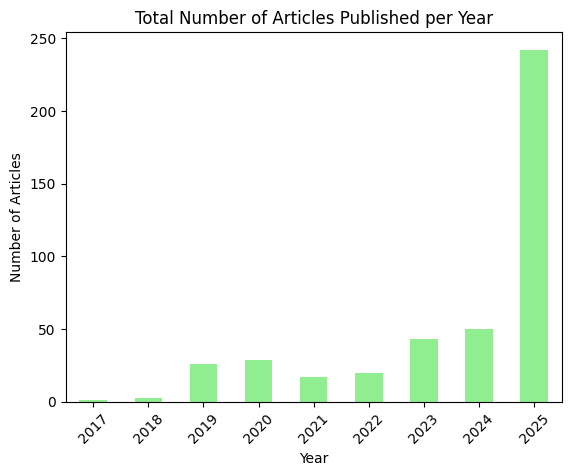

In [55]:
year_counts = df['year'].value_counts().sort_index()

year_counts.plot(kind = 'bar', color = 'LightGreen')

plt.xlabel("Year")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.title("Total Number of Articles Published per Year")
plt.show()


#### Stacked Bar Chart

In [56]:
year_counts = df.groupby(['year', 'media_name']).size().unstack().fillna(0)
year_counts['total'] = year_counts.sum(axis=1)
year_counts = year_counts.sort_index()
year_percentage = year_counts.div(year_counts['total'], axis=0) * 100

year_percentage_filtered = year_percentage[year_percentage.index >= 2015]

In [57]:
palette = sns.color_palette("tab20") + sns.color_palette("tab20b")

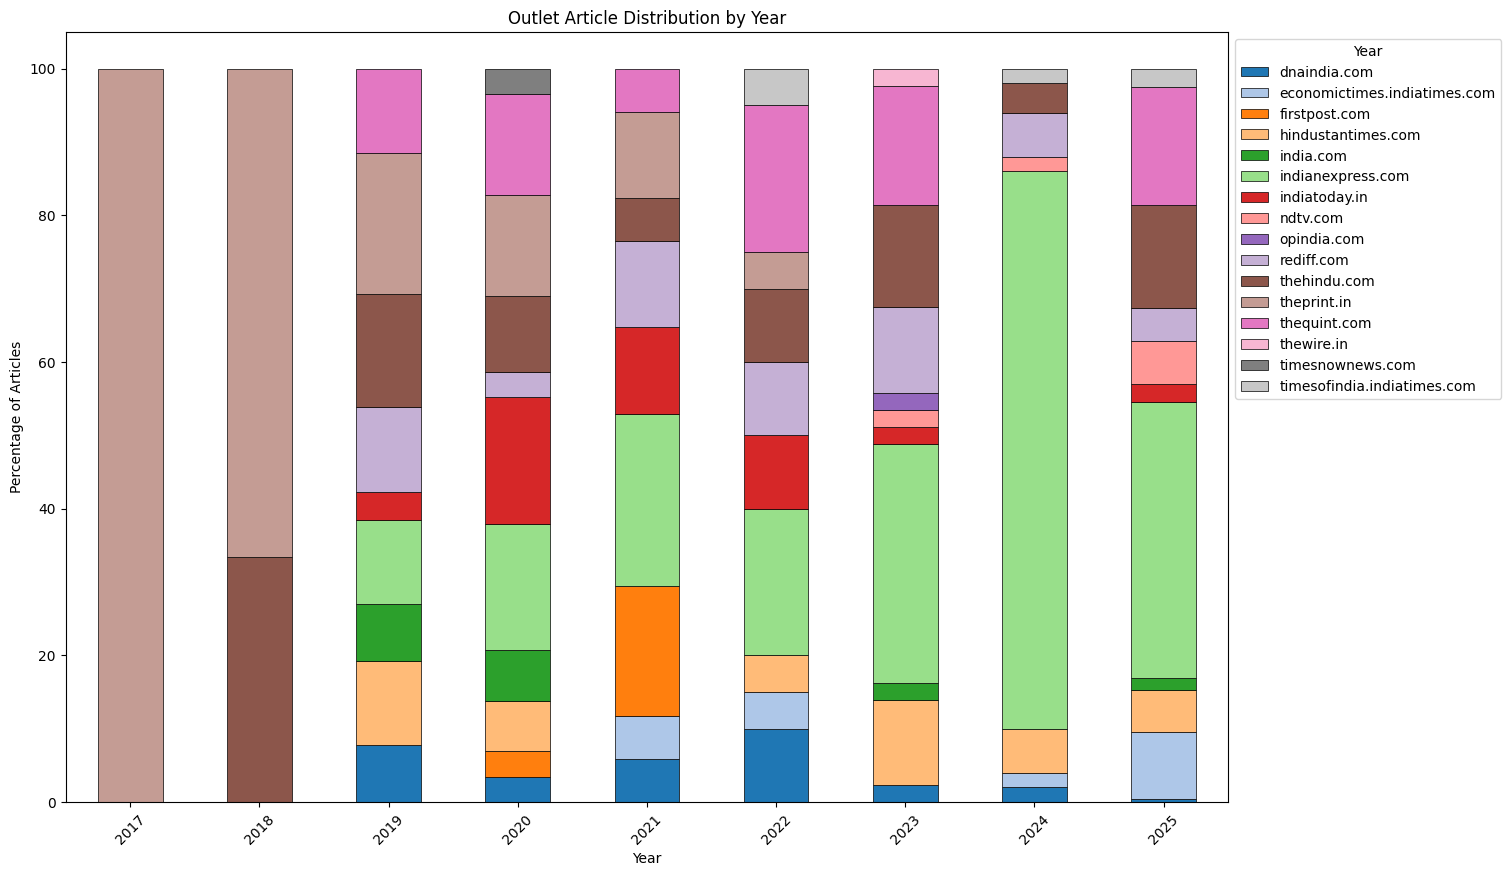

In [58]:
year_percentage_filtered.drop('total', axis=1).plot(kind='bar', stacked=True, color=palette, figsize=(15,10), edgecolor='black', linewidth=0.5)

plt.xlabel('Year')
plt.xticks(rotation=45)
plt.ylabel('Percentage of Articles')
plt.title('Outlet Article Distribution by Year')
plt.legend(title='Year', bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

#### Overall Box Plot

In [59]:
yearly_counts = df.groupby(['media_name', 'year']).size().reset_index(name='count').fillna(0)

yearly_counts = yearly_counts[yearly_counts['year'] >= 2015]

yearly_counts

,media_name,year,count
0,dnaindia.com,2019,2
1,dnaindia.com,2020,1
2,dnaindia.com,2021,1
3,dnaindia.com,2022,2
4,dnaindia.com,2023,1
...,...,...,...
67,thewire.in,2023,1
68,timesnownews.com,2020,1
69,timesofindia.indiatimes.com,2022,1
70,timesofindia.indiatimes.com,2024,1


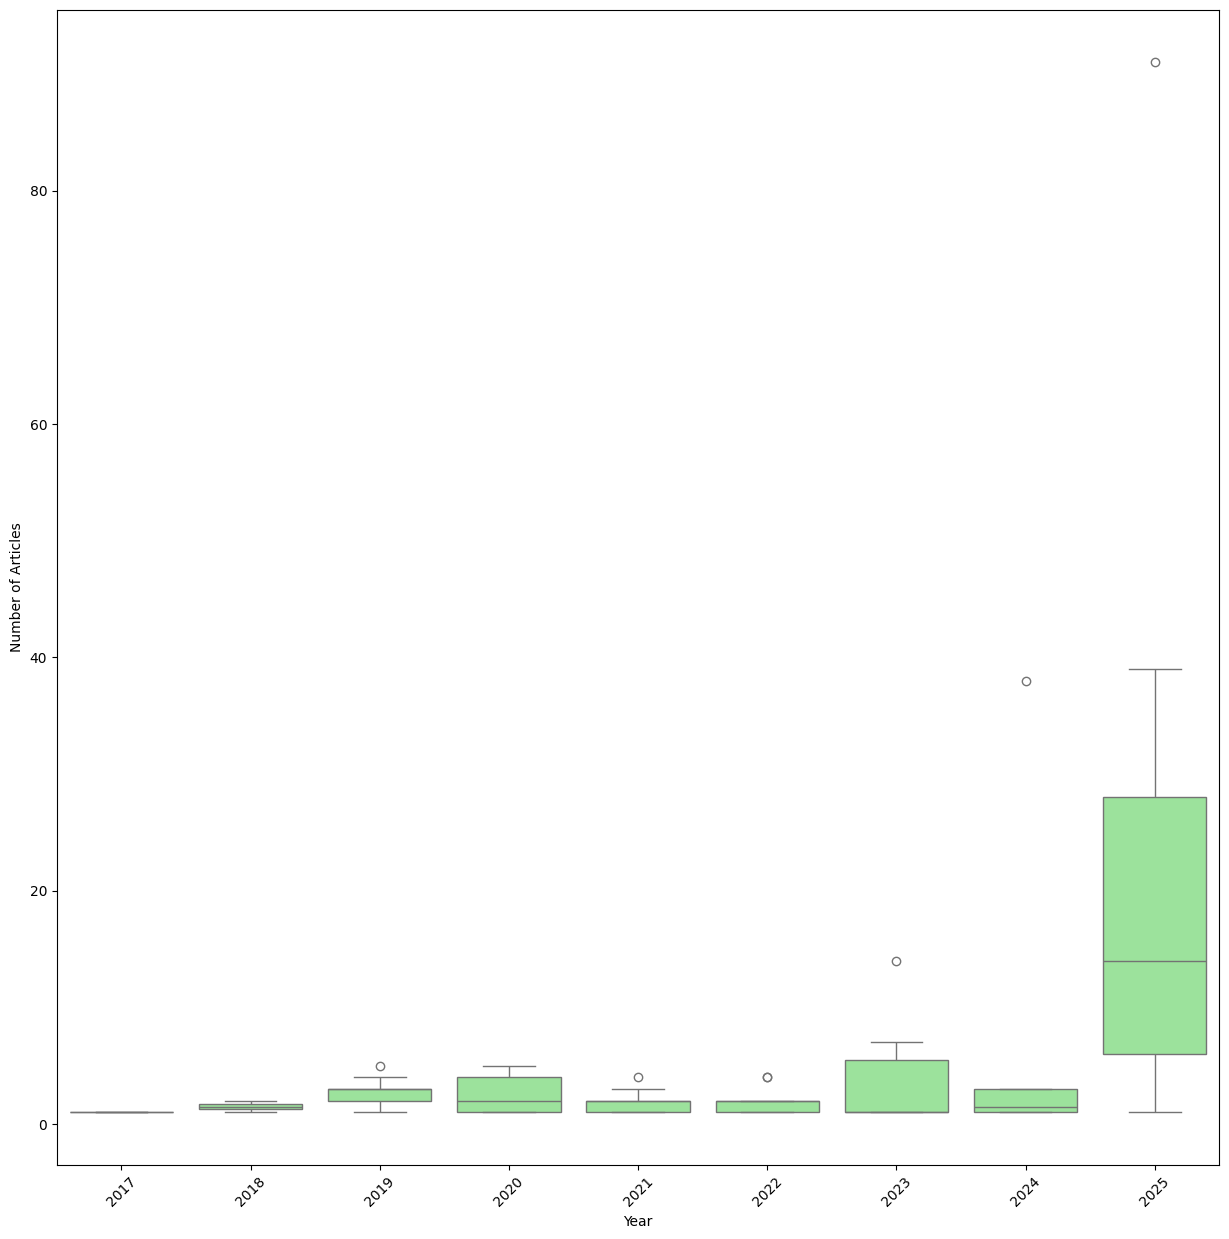

In [60]:
plt.figure(figsize=(15, 15))
plt.xticks(rotation=45)
plt.xlabel('Year')
plt.ylabel('Number of Articles')

sns.boxplot(data=yearly_counts, x='year', y='count', color='LightGreen')

plt.show()